  ## STUDENT NAME : NIKHIL SHIVAJI MALI
  ## DIV:- B
  ## PEACTICAL BATCH:- B-1
  ## ROLL NO:- 03
  ## DATE:- 07/10/2026
  ## PRACTICAL NO:- 05
  ## PRACTICAL NAME:- Train a linear and kernal(RBF,polynomial)SVM. Tune C and gamma hyperparameters

# 1] IMPORT LIBRARIES

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

import seaborn as sns 
from sklearn.svm import SVC

# 2]LOAD AND PREVIEW DATASET 

In [4]:
df = pd.read_csv("Non_linear_SVM_Dataset.csv")
df

,X1,X2,Y
0,0.830858,-0.334342,1.0
1,0.991710,0.879000,0.0
2,1.107245,-0.470344,1.0
3,-0.140899,1.033148,0.0
4,0.405592,1.328529,0.0
...,...,...,...
495,0.265123,1.023197,0.0
496,0.193576,-0.011663,1.0
497,0.345548,-0.128434,1.0
498,1.403890,-0.466993,1.0


In [5]:
df.info()  #shows structure of data 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      500 non-null    float64
 1   X2      500 non-null    float64
 2   Y       500 non-null    float64
dtypes: float64(3)
memory usage: 11.8 KB


# 3]Feature and Target Splitting 

In [7]:
Y = df["Y"]   #output 
X = df.drop(columns='Y') # Input
X.head()

,X1,X2
0,0.830858,-0.334342
1,0.991710,0.879000
2,1.107245,-0.470344
3,-0.140899,1.033148
4,0.405592,1.328529


# 4] Exploratory Data Analysis & Visualization

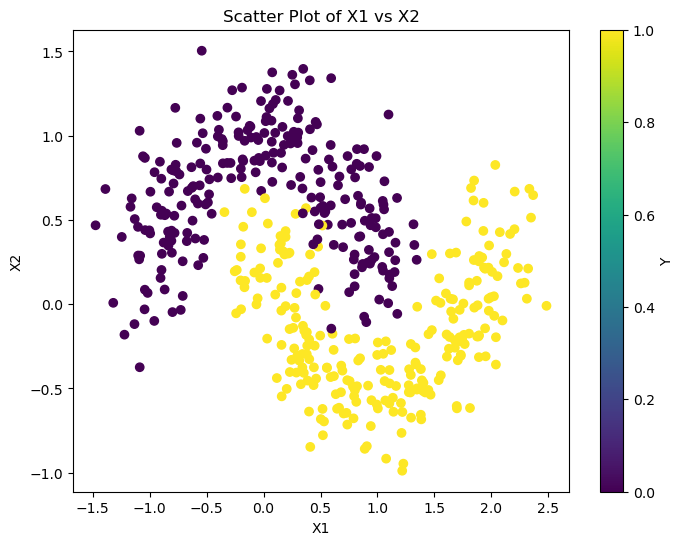

In [8]:
plt.figure(figsize=(8, 6))

plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=Y, cmap='viridis') # Use Y for color mapping
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Scatter Plot of X1 vs X2")
plt.colorbar(label="Y") # Show colorbar to represent values in Y
plt.show()

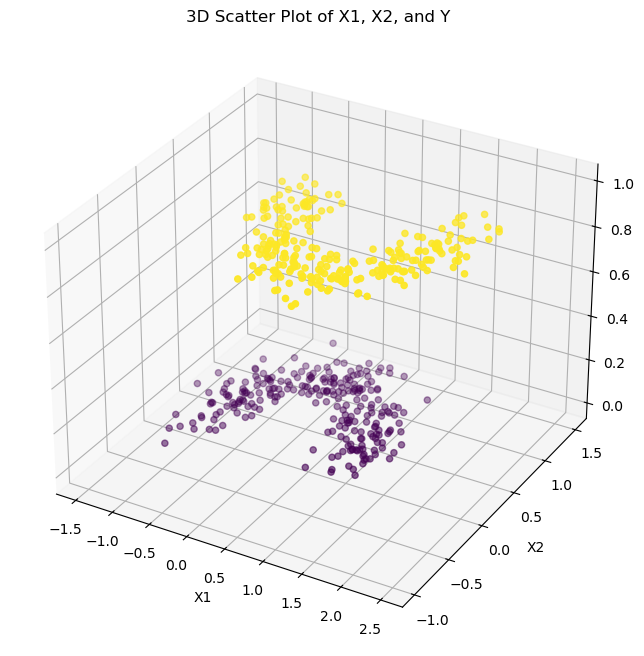

In [9]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X['X1'], X['X2'], Y, c=Y, cmap='viridis')

ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('Y')
ax.set_title('3D Scatter Plot of X1, X2, and Y')
plt.show()

# 5]Train-Test Split

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42
)

# 6] Model Training & Evaluation (Linear Kernel)

In [12]:
from sklearn.svm import SVC

linear_svm = SVC(kernel='linear')
linear_svm.fit(X_train, y_train)



,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [13]:
from sklearn.metrics import accuracy_score

y_pred_linear = linear_svm.predict(X_test)

print("Linear SVM Accuracy:",
      accuracy_score(y_test, y_pred_linear))

Linear SVM Accuracy: 0.8666666666666667


# 7]Model Training (RBF Kernel)

In [16]:
rbf_svm = SVC(kernel='rbf' , C=10 , gamma='scale')
rbf_svm.fit(X_train , y_train)
y_pred_rbf = rbf_svm.predict(X_test)


print("RBF SVM Accuracy:" , accuracy_score(y_test,y_pred_rbf))

RBF SVM Accuracy: 0.9866666666666667


# 8] Model Traning (Polynomial Kernal)

In [17]:
poly_svm = SVC(kernel='poly', C=10, degree=2)

poly_svm.fit(X_train, y_train)

y_pred_poly = poly_svm.predict(X_test)

print("Polynomial SVM Accuracy:",
      accuracy_score(y_test, y_pred_poly))

Polynomial SVM Accuracy: 0.7866666666666666


# 9] Hyperparameter Tuning via Grid Search

In [21]:
from sklearn.model_selection import GridSearchCV

params = {'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.1, 1]}

grid = GridSearchCV(SVC(kernel='rbf'),
    params,cv=5,scoring='accuracy')

grid.fit(X_train, y_train)

print("\nBest Parameters:")
print(grid.best_params_)



Best Parameters:
{'C': 1, 'gamma': 'scale'}


# 10] Evaluate Best Tuned Model

In [22]:
from sklearn.metrics import classification_report

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("\nTuned RBF SVM Accuracy:",
      accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Tuned RBF SVM Accuracy: 0.98

Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      1.00      0.98        75
         1.0       1.00      0.96      0.98        75

    accuracy                           0.98       150
   macro avg       0.98      0.98      0.98       150
weighted avg       0.98      0.98      0.98       150

